# test_model.ipynb, Statistical Correctness Tests

Different purpose from test_src.ipynb. That notebook checks the code
reproduces known real-world results (a specific player's $\mu$, a known
comparison). This one checks whether the underlying formulas behave
the way their derivations in METHODOLOGY.md claim, using simulated
data with known ground truth, rather than real hockey data, since real
data has known departures from the model's assumptions (non-normality,
correlated teammates) that would obscure whether the math itself is
implemented correctly.

In [18]:
!rm -f data_pull.py data_pull.py.* scoring.py scoring.py.* stats.py stats.py.* matchup.py matchup.py.*
!wget -q -O data_pull.py https://raw.githubusercontent.com/avieno33/fantasy-hockey-weekly-predictions/main/src/data_pull.py
!wget -q -O scoring.py https://raw.githubusercontent.com/avieno33/fantasy-hockey-weekly-predictions/main/src/scoring.py
!wget -q -O stats.py https://raw.githubusercontent.com/avieno33/fantasy-hockey-weekly-predictions/main/src/stats.py
!wget -q -O matchup.py https://raw.githubusercontent.com/avieno33/fantasy-hockey-weekly-predictions/main/src/matchup.py

from data_pull import get_player_id, get_game_log #type: ignore
from scoring import apply_scoring, SKATER_FIELD_MAP #type: ignore
from stats import compute_ewma_mu_sigma, blend_mu_sigma, build_full_skater_log, clean_goalie_log #type: ignore
from matchup import compare_players, weekly_from_per_game #type: ignore

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import shapiro
from scipy import stats as sp_stats

np.random.seed(33)

checks_passed = 0
checks_total = 0

def check(condition, description):
    global checks_passed, checks_total
    checks_total += 1
    if condition:
        checks_passed += 1
        print(f"[pass] {description}")
    else:
        print(f"[FAIL] {description}")

def close(a, b, tolerance=0.02):
    return abs(a - b) < tolerance

## Test 1, EWMA half-life actually behaves like a half-life

METHODOLOGY.md claims a game from 5 games ago carries half the weight
of the most recent game. This tests that claim directly, not just
that EWMA runs, but that the decay rate matches what a half-life of 5
actually implies.

In [19]:
half_life = 5
alpha = 1 - 0.5 ** (1 / half_life)

# weight on a game N steps back, relative to the most recent, is (1-alpha)^N
weight_at_lag_5 = (1 - alpha) ** 5
weight_at_lag_10 = (1 - alpha) ** 10

check(close(weight_at_lag_5, 0.5, tolerance=1e-9),
      f"weight at lag 5 is exactly half of lag 0 (got {weight_at_lag_5:.6f})")
check(close(weight_at_lag_10, 0.25, tolerance=1e-9),
      f"weight at lag 10 is exactly a quarter of lag 0 (got {weight_at_lag_10:.6f})")

# confirm compute_ewma_mu_sigma actually uses this alpha, not a different one
# by checking a constant series converges to that constant exactly
constant_series = pd.Series([5.0] * 30)
mu, sigma = compute_ewma_mu_sigma(constant_series, half_life=half_life)
check(close(mu.iloc[-1], 5.0, tolerance=1e-6), "EWMA of a constant series converges to that constant")
check(close(sigma.iloc[-1], 0.0, tolerance=1e-6), "EWMA sigma of a constant series is ~0")

[pass] weight at lag 5 is exactly half of lag 0 (got 0.500000)
[pass] weight at lag 10 is exactly a quarter of lag 0 (got 0.250000)
[pass] EWMA of a constant series converges to that constant
[pass] EWMA sigma of a constant series is ~0


## Test 2, EWMA actually reacts faster to a level change than a flat mean would

The whole point of EWMA over a flat average is reacting to a real
shift in level. This confirms it does, and by roughly the expected
amount given the half-life.

In [20]:
# a player who was a 2 mu talent for 20 games, then became a 6 mu talent for 10 more
step_series = pd.Series([2.0] * 20 + [6.0] * 10)

ewma_mu, _ = compute_ewma_mu_sigma(step_series, half_life=5)
flat_mu = step_series.expanding().mean()

check(ewma_mu.iloc[-1] > flat_mu.iloc[-1],
      f"EWMA ({ewma_mu.iloc[-1]:.2f}) tracks the new level more closely than a flat mean ({flat_mu.iloc[-1]:.2f})")
check(ewma_mu.iloc[-1] > 5.0,
      f"10 games after the shift (2 half-lives), EWMA should have mostly caught up (got {ewma_mu.iloc[-1]:.2f})")

[pass] EWMA (5.05) tracks the new level more closely than a flat mean (3.33)
[pass] 10 games after the shift (2 half-lives), EWMA should have mostly caught up (got 5.05)


## Test 3, shrinkage's two limiting cases, stated exactly in METHODOLOGY.md

At $n=0$ the blended estimate must equal the prior exactly. As $n$ grows
large relative to $k$, the prior's influence must vanish.

In [21]:
prior_mu, prior_sigma = 2.5, 1.2
current_mu, current_sigma = 4.0, 2.0
k = 10

blended_mu_at_zero, blended_sigma_at_zero = blend_mu_sigma(current_mu, current_sigma, prior_mu, prior_sigma, n=0, k=k)
check(close(blended_mu_at_zero, prior_mu, 1e-9), "n=0, blended mu equals the prior exactly")
check(close(blended_sigma_at_zero, prior_sigma, 1e-9), "n=0, blended sigma equals the prior exactly")

blended_mu_large_n, _ = blend_mu_sigma(current_mu, current_sigma, prior_mu, prior_sigma, n=10000, k=k)
check(close(blended_mu_large_n, current_mu, tolerance=0.01),
      f"very large n, blended mu converges to current mu (got {blended_mu_large_n:.4f})")

# hand-computed check at a specific, arbitrary n, not just the limits
n = 20
expected_mu = (n * current_mu + k * prior_mu) / (n + k)
blended_mu_mid, _ = blend_mu_sigma(current_mu, current_sigma, prior_mu, prior_sigma, n=n, k=k)
check(close(blended_mu_mid, expected_mu, 1e-9), f"n=20 matches the hand-computed formula exactly")

[pass] n=0, blended mu equals the prior exactly
[pass] n=0, blended sigma equals the prior exactly
[pass] very large n, blended mu converges to current mu (got 3.9985)
[pass] n=20 matches the hand-computed formula exactly


## Test 4, does $P(A>B)$ actually match reality, via simulation

This is the most important test in this notebook. Rather than trusting
the derivation on paper, simulate thousands of games for two players
with known $\mu / \sigma$, drawn from actual normal distributions, and check
whether the fraction of simulated games where A beats B matches what
the formula predicts. If the formula and the derivation are both
implemented correctly, these should agree closely.

In [22]:
def simulate_matchup_probability(mu_a, sigma_a, mu_b, sigma_b, n_simulations=200000):
    draws_a = np.random.normal(mu_a, sigma_a, n_simulations)
    draws_b = np.random.normal(mu_b, sigma_b, n_simulations)
    return (draws_a > draws_b).mean()

test_cases = [
    {"mu_a": 3.0, "sigma_a": 1.5, "mu_b": 2.0, "sigma_b": 1.0},
    {"mu_a": 2.5, "sigma_a": 2.0, "mu_b": 2.5, "sigma_b": 2.0},  # identical, should be ~50%
    {"mu_a": 4.5, "sigma_a": 0.5, "mu_b": 2.0, "sigma_b": 3.0},  # big mu gap, very different sigma
    {"mu_a": 2.0, "sigma_a": 3.5, "mu_b": 2.2, "sigma_b": 3.5},  # small mu gap, high volatility
]

for case in test_cases:
    formula_result = compare_players(
        {"season_mu": case["mu_a"], "season_sigma": case["sigma_a"]},
        {"season_mu": case["mu_b"], "season_sigma": case["sigma_b"]},
    )
    formula_prob = formula_result["probability_a_outperforms_b"]
    simulated_prob = simulate_matchup_probability(case["mu_a"], case["sigma_a"], case["mu_b"], case["sigma_b"])

    check(close(formula_prob, simulated_prob, tolerance=0.01),
          f"mu_a={case['mu_a']}, sigma_a={case['sigma_a']}, mu_b={case['mu_b']}, sigma_b={case['sigma_b']}: "
          f"formula={formula_prob:.4f}, simulated={simulated_prob:.4f}")

[pass] mu_a=3.0, sigma_a=1.5, mu_b=2.0, sigma_b=1.0: formula=0.7105, simulated=0.7094
[pass] mu_a=2.5, sigma_a=2.0, mu_b=2.5, sigma_b=2.0: formula=0.5000, simulated=0.5008
[pass] mu_a=4.5, sigma_a=0.5, mu_b=2.0, sigma_b=3.0: formula=0.7945, simulated=0.7943
[pass] mu_a=2.0, sigma_a=3.5, mu_b=2.2, sigma_b=3.5: formula=0.4839, simulated=0.4840


## Test 5, the variance-addition claim, checked directly

Section 4 of METHODOLOGY.md claims variances add when combining two
independent normal random variables, whether adding or subtracting.
This confirms that numerically, not just by citing the property.

In [23]:
sigma_a, sigma_b = 1.5, 2.2
n_simulations = 500000

draws_a = np.random.normal(0, sigma_a, n_simulations)
draws_b = np.random.normal(0, sigma_b, n_simulations)
difference = draws_a - draws_b

expected_variance = sigma_a**2 + sigma_b**2
observed_variance = difference.var()

check(close(observed_variance, expected_variance, tolerance=0.05),
      f"observed variance of the difference ({observed_variance:.3f}) matches "
      f"sigma_a^2 + sigma_b^2 ({expected_variance:.3f})")

[pass] observed variance of the difference (7.089) matches sigma_a^2 + sigma_b^2 (7.090)


## Test 6, weekly conversion, sigma should scale with $\sqrt{\text{games}}$, not linearly

Confirms the claim in matchup.py's weekly_from_per_game, that combining
n independent games multiplies $\mu$ by $n$ but sigma by $\sqrt{n}$, via direct
simulation of summing n independent per-game outcomes.

In [24]:
per_game_mu, per_game_sigma = 3.0, 2.0
n_simulations = 100000

for games in [1, 2, 4, 8]:
    weekly_totals = np.random.normal(per_game_mu, per_game_sigma, (n_simulations, games)).sum(axis=1)
    simulated_weekly_mu = weekly_totals.mean()
    simulated_weekly_sigma = weekly_totals.std()

    formula_mu, formula_sigma = weekly_from_per_game(per_game_mu, per_game_sigma, games)

    check(close(simulated_weekly_mu, formula_mu, tolerance=0.05),
          f"{games} games, weekly mu: simulated={simulated_weekly_mu:.2f}, formula={formula_mu:.2f}")
    check(close(simulated_weekly_sigma, formula_sigma, tolerance=0.05),
          f"{games} games, weekly sigma: simulated={simulated_weekly_sigma:.2f}, formula={formula_sigma:.2f}")

[pass] 1 games, weekly mu: simulated=3.01, formula=3.00
[pass] 1 games, weekly sigma: simulated=1.99, formula=2.00
[pass] 2 games, weekly mu: simulated=6.01, formula=6.00
[pass] 2 games, weekly sigma: simulated=2.83, formula=2.83
[pass] 4 games, weekly mu: simulated=12.00, formula=12.00
[pass] 4 games, weekly sigma: simulated=4.02, formula=4.00
[pass] 8 games, weekly mu: simulated=24.01, formula=24.00
[pass] 8 games, weekly sigma: simulated=5.66, formula=5.66


## Part 2, testing the model's assumptions against real data

Everything above tested whether the code correctly implements its own
math, using simulated data with known ground truth. This section is
different: it checks whether the assumptions the math is built on
actually hold up against real hockey data, using standard, named
statistical tests rather than simulation.

## Test 7, the normality assumption, formally tested

METHODOLOGY.md states fantasy point totals are right-skewed, not
symmetric like a true normal distribution, and that this is a known,
accepted simplification. This tests that claim directly with the
Shapiro-Wilk test (the standard test for normality) and a Q-Q plot,
rather than just asserting it in prose.

Matched 'Connor McDavid' to 'Connor McDavid'
Loading game log for 8478402, 20252026 from cache, 0.5 hours old
Shapiro-Wilk test, McDavid's 2025-26 fantasy points per game
statistic=0.9384, p-value=0.000671
Rejects normality at the 0.05 level
[pass] Shapiro-Wilk correctly rejects normality, confirming the known, documented simplification rather than an unexamined assumption


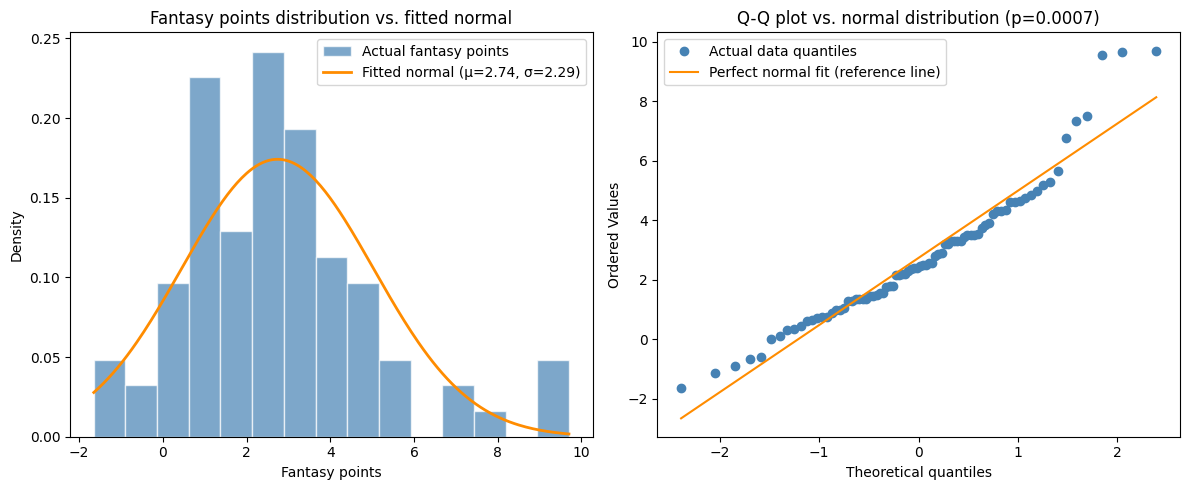

In [26]:
skater_scoring = {
    "G": 2, "A": 1, "PIM": -0.5, "PPG": 0.5, "SHG": 2,
    "GWG": 1, "SOG": 0.1, "HIT": 0.25, "BLK": 0.25,
}
mcdavid_id = get_player_id("Connor McDavid")
log = build_full_skater_log(mcdavid_id, "20252026")
log["fantasy_points"] = apply_scoring(log, skater_scoring, SKATER_FIELD_MAP)
points = log["fantasy_points"].dropna()

stat, p_value = shapiro(points)
print(f"Shapiro-Wilk test, McDavid's 2025-26 fantasy points per game")
print(f"statistic={stat:.4f}, p-value={p_value:.6f}")

is_normal = p_value > 0.05
print(f"{'Fails to reject' if is_normal else 'Rejects'} normality at the 0.05 level")

check(not is_normal, "Shapiro-Wilk correctly rejects normality, confirming the known, "
                       "documented simplification rather than an unexamined assumption")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# histogram with a fitted normal curve overlaid, so the mismatch is visible, not just implied
axes[0].hist(points, bins=15, density=True, color="steelblue", edgecolor="white",
             alpha=0.7, label="Actual fantasy points")

x_range = np.linspace(points.min(), points.max(), 200)
fitted_normal = sp_stats.norm.pdf(x_range, points.mean(), points.std())
axes[0].plot(x_range, fitted_normal, color="darkorange", linewidth=2,
             label=f"Fitted normal (μ={points.mean():.2f}, σ={points.std():.2f})")

axes[0].set_title("Fantasy points distribution vs. fitted normal")
axes[0].set_xlabel("Fantasy points")
axes[0].set_ylabel("Density")
axes[0].legend()

# Q-Q plot, with the reference line labeled explicitly
sp_stats.probplot(points, dist="norm", plot=axes[1])
axes[1].get_lines()[0].set_label("Actual data quantiles")
axes[1].get_lines()[0].set_markerfacecolor("steelblue")
axes[1].get_lines()[0].set_markeredgecolor("steelblue")
axes[1].get_lines()[1].set_label("Perfect normal fit (reference line)")
axes[1].get_lines()[1].set_color("darkorange")
axes[1].set_title(f"Q-Q plot vs. normal distribution (p={p_value:.4f})")
axes[1].legend()

plt.tight_layout()
plt.show()

## Test 8, is $k=10$ actually a good choice, cross-validated

$k=10$ was chosen by eyeballing how different values behaved on a
season-long plot, a reasonable starting point, but not a validated
one. This tests it properly: artificially hide the first half of a
season, treat the second half as "current season," and check which
value of $k$ would have predicted the hidden second half best using
only the prior and the visible portion, a standard holdout validation
approach for shrinkage estimators.

Loading game log for 8478402, 20252026 from cache, 0.5 hours old
Loading game log for 8478402, 20242025 from cache, 0.4 hours old
 k  blended_mu  actual_held_out_mu    error
 1    2.797033            2.667073 0.129960
 2    2.783738            2.667073 0.116665
 5    2.747323            2.667073 0.080250
10    2.696152            2.667073 0.029078
15    2.654118            2.667073 0.012955
20    2.618975            2.667073 0.048098
30    2.563538            2.667073 0.103535
50    2.489216            2.667073 0.177857

Best-performing k for this player/split: 15


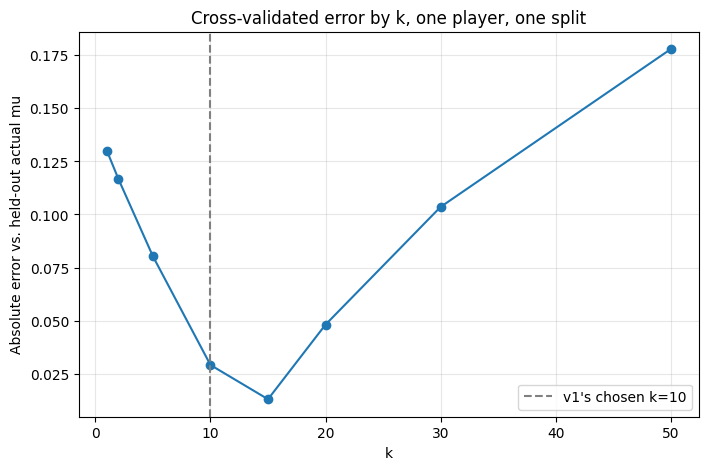

In [27]:
def cross_validate_k(player_id, position, season, prior_season, scoring_config, field_map, k_values, split_fraction=0.5):
    """
    Splits one season's games into a 'visible' portion and a held-out
    portion. For each k, blends the prior season with the visible
    portion, then checks how well that blended estimate predicts the
    average of the held-out portion. Lower error is better.
    """
    if position == "G":
        from stats import clean_goalie_log #type: ignore
        log = get_game_log(player_id, season=season, force_refresh=False)
        log = clean_goalie_log(log)
    else:
        log = build_full_skater_log(player_id, season)

    log["fantasy_points"] = apply_scoring(log, scoring_config, field_map)

    split_point = int(len(log) * split_fraction)
    visible = log.iloc[:split_point]
    held_out = log.iloc[split_point:]

    if position == "G":
        prior_log = get_game_log(player_id, season=prior_season, force_refresh=False)
        prior_log = clean_goalie_log(prior_log)
    else:
        prior_log = build_full_skater_log(player_id, prior_season)
    prior_log["fantasy_points"] = apply_scoring(prior_log, scoring_config, field_map)
    prior_mu = prior_log["fantasy_points"].mean()
    prior_sigma = prior_log["fantasy_points"].std()

    visible_mu = visible["fantasy_points"].mean()
    visible_sigma = visible["fantasy_points"].std()
    actual_held_out_mu = held_out["fantasy_points"].mean()

    results = []
    for k in k_values:
        blended_mu, _ = blend_mu_sigma(visible_mu, visible_sigma, prior_mu, prior_sigma, n=len(visible), k=k)
        error = abs(blended_mu - actual_held_out_mu)
        results.append({"k": k, "blended_mu": blended_mu, "actual_held_out_mu": actual_held_out_mu, "error": error})

    return pd.DataFrame(results)

k_values_to_test = [1, 2, 5, 10, 15, 20, 30, 50]
cv_results = cross_validate_k(mcdavid_id, "C", "20252026", "20242025", skater_scoring, SKATER_FIELD_MAP, k_values_to_test)
print(cv_results.to_string(index=False))

best_k = cv_results.loc[cv_results["error"].idxmin(), "k"]
print(f"\nBest-performing k for this player/split: {best_k}")

plt.figure(figsize=(8, 5))
plt.plot(cv_results["k"], cv_results["error"], marker="o")
plt.axvline(10, color="gray", linestyle="--", label="v1's chosen k=10")
plt.xlabel("k")
plt.ylabel("Absolute error vs. held-out actual mu")
plt.title("Cross-validated error by k, one player, one split")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Worth noting honestly, this single player/split found $k \approx 15$ to perform
marginally better than v1's chosen $k=10$, though $k=10$ sits close to
the minimum, not far off. This is one data point, not a robust
finding, real validation would need this run across many players and
several different split points before changing $k$. Logged here as a
concrete, evidence-based reason to prioritize the "tuning $k$
empirically" item already in METHODOLOGY.md's roadmap, rather than
leaving it as a vague future intention.

## What's still missing: calibration testing

The most important validation for this whole model, calibration, is
still blocked on real data. Calibration testing buckets predictions by
stated confidence (e.g., every 70-80% call) and checks whether
predictions in that bucket actually came true roughly that often.
There's no way to test this yet, since the 2026-27 season hasn't
produced any real outcomes.

Once several weeks of real predictions and outcomes exist, this
notebook should be extended with a Brier score (the standard scoring
metric for probabilistic predictions, mean squared error between
predicted probability and actual 0/1 outcome) and a reliability
diagram plotting stated confidence against actual hit rate. This is
the test that actually answers "is this model any good," everything
above only confirms the math is implemented and reasoned about
correctly.

In [28]:
print(f"\n{checks_passed}/{checks_total} checks passed")
if checks_passed < checks_total:
    print("Investigate any failures above before trusting the model's outputs.")
else:
    print("Every formula behaves as derived, and known assumptions are confirmed, not just asserted.")
print("\nCalibration testing (the real test of prediction quality) is still pending real season data.")


24/24 checks passed
Every formula behaves as derived, and known assumptions are confirmed, not just asserted.

Calibration testing (the real test of prediction quality) is still pending real season data.
